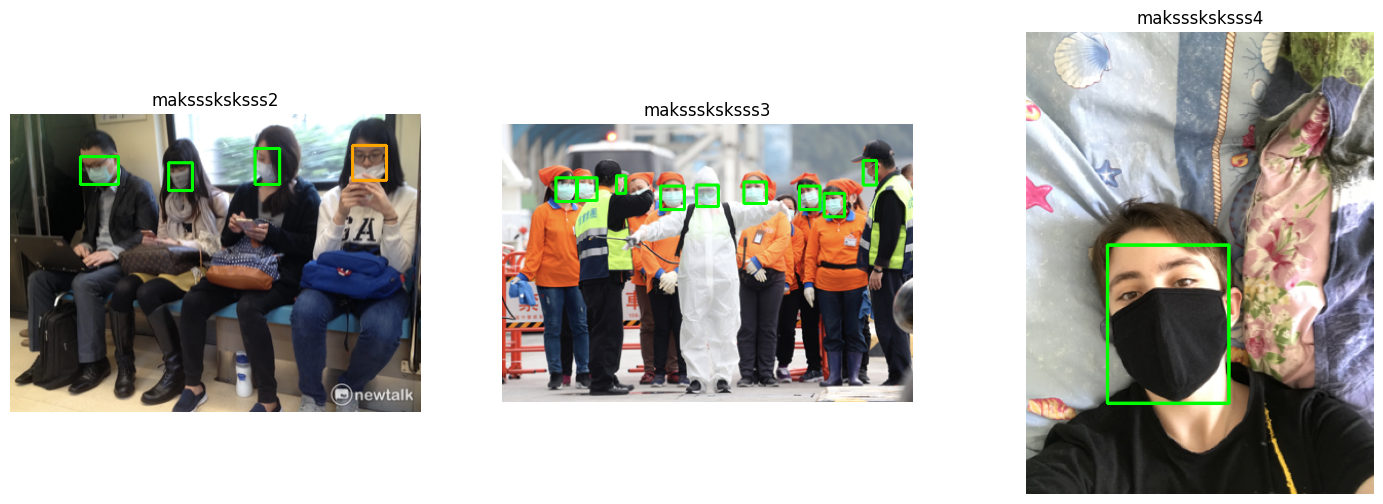

In [2]:
import os, cv2
import matplotlib.pyplot as plt

LBL_DIR = "../data/yolo_labels"
IMG_DIR = "../data/images"
COLORS = [(0, 255, 0), (0, 0, 255), (0, 165, 255)]

def yolo_to_box(xc, yc, w, h, img_w, img_h):
    x1 = int((xc - w / 2) * img_w)
    y1 = int((yc - h / 2) * img_h)
    x2 = int((xc + w / 2) * img_w)
    y2 = int((yc + h / 2) * img_h)
    return x1, y1, x2, y2

stems = ["maksssksksss2", "maksssksksss3", "maksssksksss4"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, stem in zip(axes, stems):
    img = cv2.imread(os.path.join(IMG_DIR, stem + ".png"))
    img_h, img_w = img.shape[:2]
    with open(os.path.join(LBL_DIR, stem + ".txt")) as f:
        for line in f.read().splitlines():
            cls, xc, yc, w, h = line.split()
            x1, y1, x2, y2 = yolo_to_box(float(xc), float(yc), float(w), float(h), img_w, img_h)
            cv2.rectangle(img, (x1, y1), (x2, y2), COLORS[int(cls)], 2)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(stem)
    ax.axis("off")
plt.show()